<a href="https://colab.research.google.com/github/berrinaydogmus/softito-yapay-zeka/blob/main/python5_pandas3_17_09_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#1 Hazırlık ve Ortam Ayarları
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
np.random.seed(42)

In [4]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

In [5]:
#2 Örnek Veri Setinin Oluşturulması
n = 1000

df = pd.DataFrame({
    "yas": np.random.randint(18, 70, size=n),
    "gelir": np.random.normal(25000, 8000, size=n).round(2),
    "sehir": np.random.choice(["İstanbul", "Ankara", "İzmir", "Bursa"], size=n),
    "abonelik_tipi": np.random.choice(["Temel", "Standart", "Premium"], size=n),
    "kayit_tarihi": pd.to_datetime(np.random.choice(pd.date_range("2023-01-01", "2026-01-01"), size=n)),
    "aylik_harcama": np.random.normal(500, 150, size=n).round(2),
    "memnuniyet_puani": np.random.randint(1, 6, size=n),
    "churn": np.random.choice([0, 1], size=n, p=[0.8, 0.2])
})

print(df.head())

   yas    gelir     sehir abonelik_tipi kayit_tarihi  aylik_harcama  \
0   56 12148.43  İstanbul         Temel   2025-12-24         395.00   
1   69 26627.71    Ankara      Standart   2024-08-17         339.88   
2   46 18949.19     Bursa       Premium   2023-09-23         444.36   
3   32 13621.97     İzmir       Premium   2025-03-31         467.54   
4   60 19827.42  İstanbul       Premium   2024-10-23         521.27   

   memnuniyet_puani  churn  
0                 4      0  
1                 2      0  
2                 1      0  
3                 3      0  
4                 3      0  


In [6]:
sehir_bozuk = df["sehir"].copy()

rastgele_index = np.random.choice(df.index, size=100, replace=False)
yarisi = rastgele_index[:50]
digger_yarisi = rastgele_index[50:]

sehir_bozuk.loc[yarisi] = sehir_bozuk.loc[yarisi].str.lower()
sehir_bozuk.loc[digger_yarisi] = sehir_bozuk.loc[digger_yarisi].str.upper()

df["sehir"] = sehir_bozuk
print(df["sehir"].value_counts())

sehir
Bursa        241
İstanbul     224
Ankara       219
İzmir        216
i̇stanbul     17
İSTANBUL      14
İZMIR         13
bursa         13
BURSA         12
i̇zmir        12
ANKARA        11
ankara         8
Name: count, dtype: int64


In [7]:
#3 Kasıtlı "Kirli Veri" Enjeksiyonu
eksik_gelir_idx = np.random.choice(df.index, size=50, replace=False)
df.loc[eksik_gelir_idx, "gelir"] = np.nan

eksik_yas_idx = np.random.choice(df.index, size=30, replace=False)
df.loc[eksik_yas_idx, "yas"] = np.nan

eksik_memnuniyet_idx = np.random.choice(df.index, size=40, replace=False)
df.loc[eksik_memnuniyet_idx, "memnuniyet_puani"] = np.nan

print(df.isnull().sum())

yas                 30
gelir               50
sehir                0
abonelik_tipi        0
kayit_tarihi         0
aylik_harcama        0
memnuniyet_puani    40
churn                0
dtype: int64


In [8]:
outlier_idx = np.random.choice(df.index, size=10, replace=False)
df.loc[outlier_idx, "gelir"] = np.random.uniform(200000, 500000, size=10)

print(df["gelir"].describe())

count      950.00
mean     28834.38
std      34901.58
min       1829.96
25%      20100.23
50%      25590.28
75%      30670.74
max     455904.07
Name: gelir, dtype: float64


In [9]:
anomali_idx = np.random.choice(df.index, size=8, replace=False)
yarisi = anomali_idx[:4]
digger_yarisi = anomali_idx[4:]

df.loc[yarisi, "yas"] = -5
df.loc[digger_yarisi, "yas"] = 150

print(df["yas"].describe())

count   972.00
mean     43.97
std      16.74
min      -5.00
25%      31.00
50%      44.00
75%      56.00
max     150.00
Name: yas, dtype: float64


In [10]:
tekrar_satirlar = df.sample(n=15, random_state=1)
df = pd.concat([df, tekrar_satirlar], ignore_index=True)

print(df.shape)

(1015, 8)


In [11]:
#4 Veri Setine Genel Bakış
print(df.shape)

(1015, 8)


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   yas               986 non-null    float64       
 1   gelir             964 non-null    float64       
 2   sehir             1015 non-null   object        
 3   abonelik_tipi     1015 non-null   object        
 4   kayit_tarihi      1015 non-null   datetime64[ns]
 5   aylik_harcama     1015 non-null   float64       
 6   memnuniyet_puani  974 non-null    float64       
 7   churn             1015 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(2)
memory usage: 63.6+ KB


In [13]:
print(df.head())
print(df.tail())
print(df.sample(5))

    yas     gelir     sehir abonelik_tipi kayit_tarihi  aylik_harcama  \
0 56.00  12148.43  İstanbul         Temel   2025-12-24         395.00   
1 69.00       NaN    Ankara      Standart   2024-08-17         339.88   
2 46.00 327186.85     Bursa       Premium   2023-09-23         444.36   
3   NaN  13621.97     İzmir       Premium   2025-03-31         467.54   
4 60.00  19827.42  İstanbul       Premium   2024-10-23         521.27   

   memnuniyet_puani  churn  
0              4.00      0  
1              2.00      0  
2              1.00      0  
3              3.00      0  
4              3.00      0  
       yas    gelir     sehir abonelik_tipi kayit_tarihi  aylik_harcama  \
1010 40.00      NaN    Ankara         Temel   2024-03-09         526.67   
1011 31.00 37745.49  İSTANBUL         Temel   2023-04-19         460.84   
1012 34.00 27470.66     Bursa      Standart   2023-05-01         600.48   
1013 50.00 20817.12    Ankara         Temel   2024-01-23         763.76   
1014 18.00 4

In [14]:
#5 Eksik Değer Analizi
eksik_ozet = pd.DataFrame({
    "eksik_sayisi": df.isnull().sum(),
    "benzersiz_sayisi": df.nunique(),
    "eksik_yuzdesi": (df.isnull().sum() / len(df) * 100).round(2)
})

print(eksik_ozet)

                  eksik_sayisi  benzersiz_sayisi  eksik_yuzdesi
yas                         29                54           2.86
gelir                       51               950           5.02
sehir                        0                12           0.00
abonelik_tipi                0                 3           0.00
kayit_tarihi                 0               668           0.00
aylik_harcama                0               988           0.00
memnuniyet_puani            41                 5           4.04
churn                        0                 2           0.00


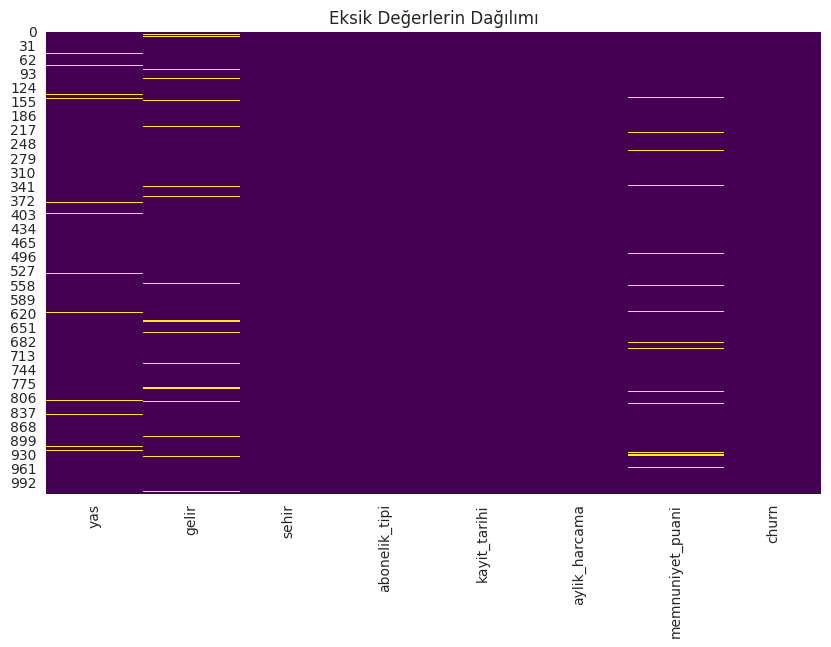

In [15]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Eksik Değerlerin Dağılımı")
plt.show()

In [16]:
#6 Yinelenen Kayıtların Tespiti
print(df.duplicated().sum())

15


In [17]:
print(df[df.duplicated()])

       yas    gelir     sehir abonelik_tipi kayit_tarihi  aylik_harcama  \
1000 43.00 25215.09     İZMIR       Premium   2025-07-16         480.48   
1001 30.00 19655.28  İstanbul      Standart   2023-01-08         750.06   
1002 66.00 28520.12  İstanbul       Premium   2024-06-15         441.28   
1003 65.00 20014.88     bursa       Premium   2023-11-27         236.89   
1004 49.00 26366.92  İstanbul       Premium   2023-05-19         573.27   
1005 21.00 29449.84    Ankara       Premium   2023-05-30         561.72   
1006 37.00 29141.27  İstanbul       Premium   2023-03-23         268.08   
1007   NaN 24951.43  İstanbul      Standart   2023-04-21         326.47   
1008 57.00 32506.27    Ankara      Standart   2024-12-16         645.53   
1009 42.00 11707.84     Bursa      Standart   2023-03-10         190.30   
1010 40.00      NaN    Ankara         Temel   2024-03-09         526.67   
1011 31.00 37745.49  İSTANBUL         Temel   2023-04-19         460.84   
1012 34.00 27470.66     B

In [18]:
#7 Kategorik Veri Temizliği
print(df["sehir"].value_counts())

sehir
Bursa        243
İstanbul     229
Ankara       224
İzmir        216
i̇stanbul     17
İSTANBUL      15
İZMIR         14
bursa         14
BURSA         12
i̇zmir        12
ANKARA        11
ankara         8
Name: count, dtype: int64


In [19]:
df["sehir"] = df["sehir"].str.lower().str.strip()
print(df["sehir"].value_counts())

sehir
bursa        269
i̇stanbul    261
ankara       243
i̇zmir       242
Name: count, dtype: int64


In [20]:
#8 Mantık Dışı Değerlerin Tespiti
anomali_yaslar = df[(df["yas"] < 0) | (df["yas"] > 100)]
print(anomali_yaslar)
print(anomali_yaslar.shape)

       yas    gelir      sehir abonelik_tipi kayit_tarihi  aylik_harcama  \
90   -5.00 27615.42  i̇stanbul         Temel   2024-02-24         729.41   
316 150.00 25226.55     ankara         Temel   2024-01-21         523.83   
387  -5.00 41081.64      bursa      Standart   2024-05-13         728.45   
424  -5.00 14121.15     i̇zmir         Temel   2025-07-02         424.24   
479 150.00 35633.22      bursa       Premium   2025-08-01         286.97   
652 150.00 23046.75     i̇zmir         Temel   2025-07-14         464.73   
698 150.00 26439.15  i̇stanbul      Standart   2023-02-27         366.73   
914  -5.00 14222.99     i̇zmir       Premium   2024-08-30         527.46   

     memnuniyet_puani  churn  
90               2.00      0  
316              4.00      0  
387               NaN      0  
424              2.00      0  
479              2.00      0  
652              2.00      0  
698              4.00      1  
914              3.00      1  
(8, 8)


In [21]:
print(anomali_yaslar.shape[0])

8


In [22]:
#9 Betimsel İstatistikler
print(df.describe())

         yas     gelir                   kayit_tarihi  aylik_harcama  \
count 986.00    964.00                           1015        1015.00   
mean   43.93  28809.16  2024-07-15 13:20:09.458128128         499.68   
min    -5.00   1829.96            2023-01-03 00:00:00          14.08   
25%    31.00  20105.32            2023-10-15 00:00:00         401.42   
50%    44.00  25611.31            2024-07-28 00:00:00         496.02   
75%    56.00  30668.14            2025-04-25 12:00:00         602.47   
max   150.00 455904.07            2026-01-01 00:00:00        1048.66   
std    16.71  34660.99                            NaN         150.28   

       memnuniyet_puani   churn  
count            974.00 1015.00  
mean               2.98    0.19  
min                1.00    0.00  
25%                2.00    0.00  
50%                3.00    0.00  
75%                4.00    0.00  
max                5.00    1.00  
std                1.42    0.39  


In [23]:
sayisal_sutunlar = ["yas", "gelir", "aylik_harcama", "memnuniyet_puani"]

for sutun in sayisal_sutunlar:
    print(sutun, "- Çarpıklık:", df[sutun].skew(), "| Basıklık:", df[sutun].kurt())

yas - Çarpıklık: 0.8809004375372087 | Basıklık: 5.142207318268953
gelir - Çarpıklık: 9.581618267448905 | Basıklık: 99.006284181045
aylik_harcama - Çarpıklık: 0.007683039778739143 | Basıklık: 0.046052435449376095
memnuniyet_puani - Çarpıklık: 0.05070785709239509 | Basıklık: -1.3251027179502426


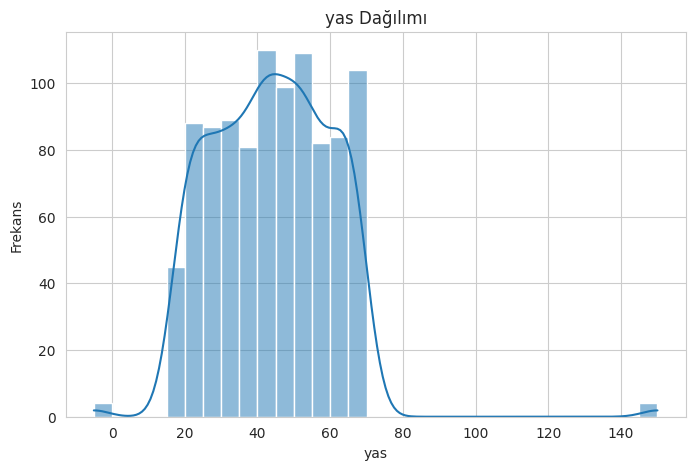

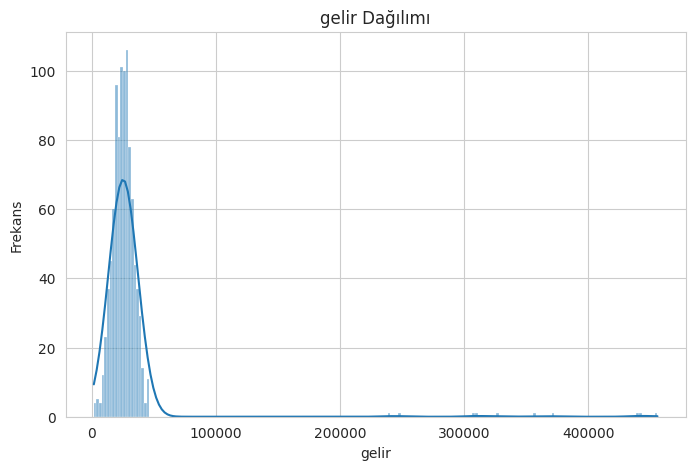

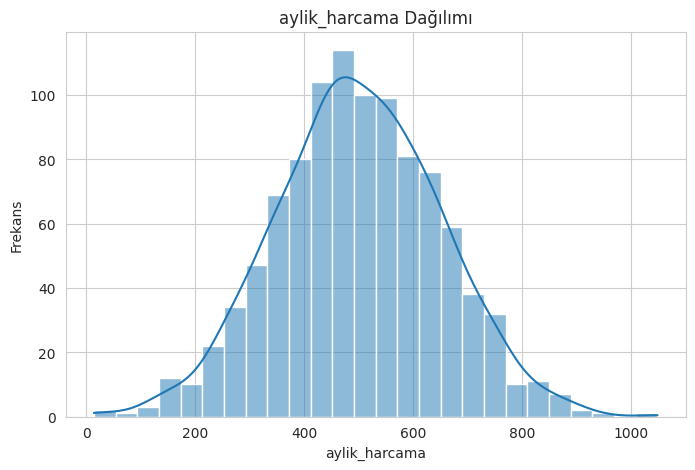

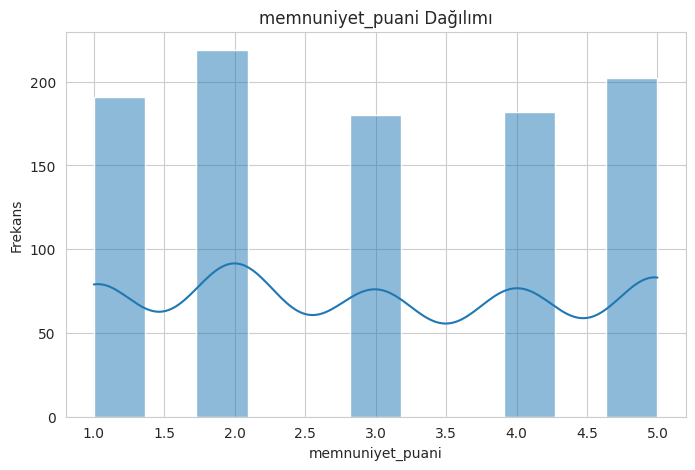

In [24]:
#10 Dağılım Görselleştirmeleri
sayisal_sutunlar = ["yas", "gelir", "aylik_harcama", "memnuniyet_puani"]

for sutun in sayisal_sutunlar:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[sutun].dropna(), kde=True)
    plt.title(f"{sutun} Dağılımı")
    plt.xlabel(sutun)
    plt.ylabel("Frekans")
    plt.show()

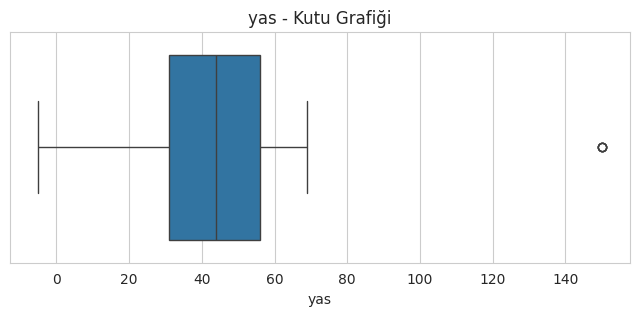

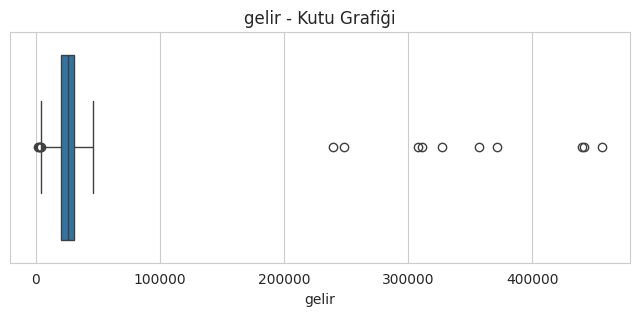

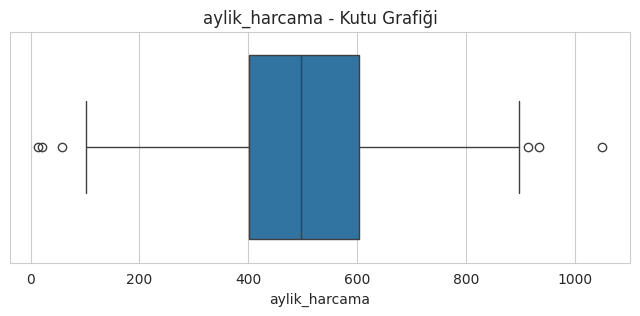

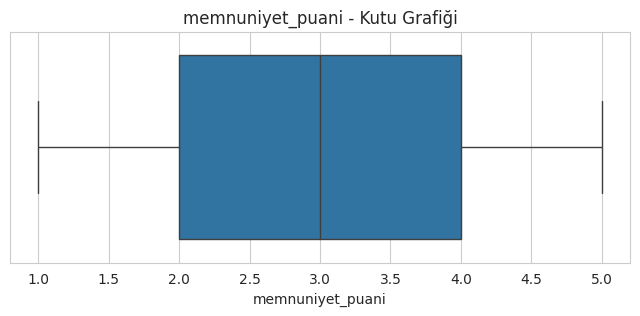

In [25]:
for sutun in sayisal_sutunlar:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[sutun])
    plt.title(f"{sutun} - Kutu Grafiği")
    plt.show()

In [26]:
#11 Kategorik Değişken Analizi
kategorik_sutunlar = ["sehir", "abonelik_tipi", "memnuniyet_puani", "churn"]

for sutun in kategorik_sutunlar:
    print(f"\n{sutun} dağılımı:")
    print(df[sutun].value_counts(normalize=True).round(4) * 100)


sehir dağılımı:
sehir
bursa       26.50
i̇stanbul   25.71
ankara      23.94
i̇zmir      23.84
Name: proportion, dtype: float64

abonelik_tipi dağılımı:
abonelik_tipi
Temel      34.78
Premium    33.69
Standart   31.53
Name: proportion, dtype: float64

memnuniyet_puani dağılımı:
memnuniyet_puani
2.00   22.48
5.00   20.74
1.00   19.61
4.00   18.69
3.00   18.48
Name: proportion, dtype: float64

churn dağılımı:
churn
0   81.18
1   18.82
Name: proportion, dtype: float64


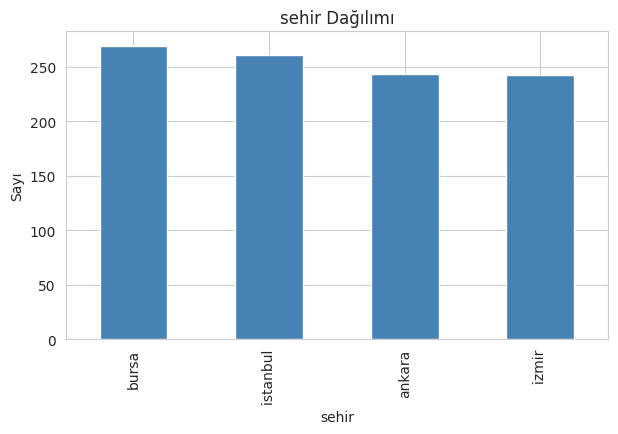

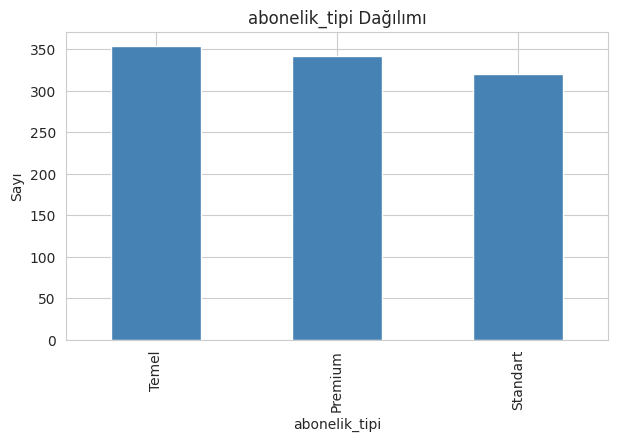

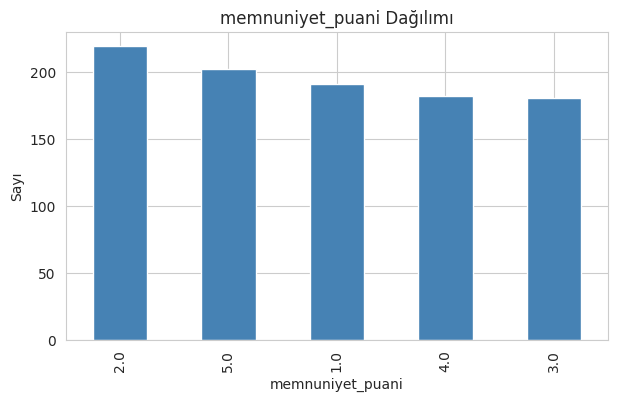

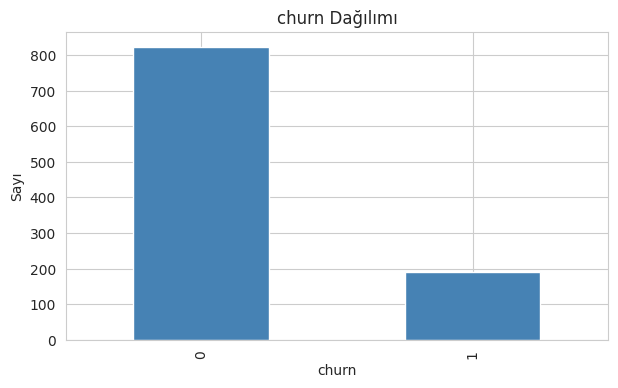

In [27]:
for sutun in kategorik_sutunlar:
    plt.figure(figsize=(7, 4))
    df[sutun].value_counts().plot(kind="bar", color="steelblue")
    plt.title(f"{sutun} Dağılımı")
    plt.xlabel(sutun)
    plt.ylabel("Sayı")
    plt.show()

In [30]:
#12 Korelasyon Analizi
korelasyon_matrisi = df[sayisal_sutunlar + ["churn"]].corr()
print(korelasyon_matrisi)

                   yas  gelir  aylik_harcama  memnuniyet_puani  churn
yas               1.00  -0.02          -0.02              0.05  -0.00
gelir            -0.02   1.00          -0.04             -0.04   0.02
aylik_harcama    -0.02  -0.04           1.00              0.04   0.03
memnuniyet_puani  0.05  -0.04           0.04              1.00  -0.04
churn            -0.00   0.02           0.03             -0.04   1.00


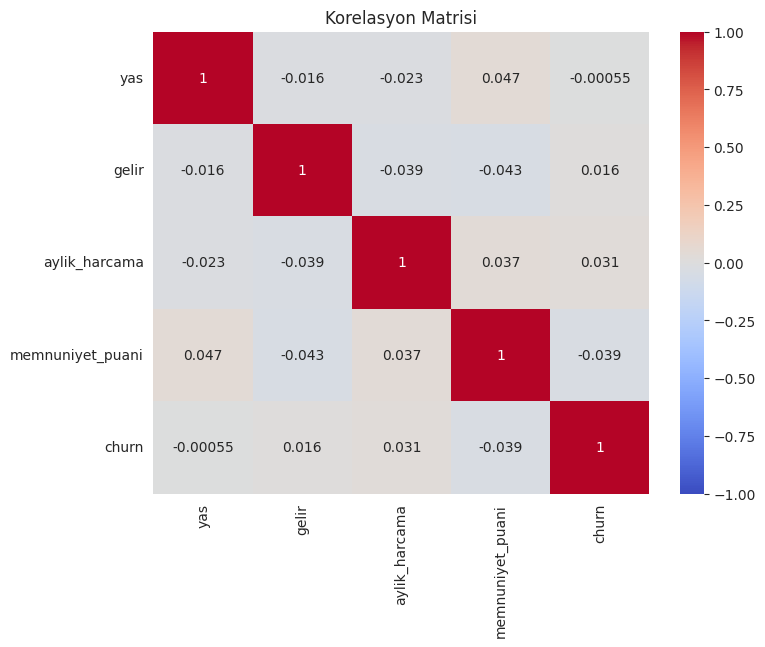

In [31]:
plt.figure(figsize=(8, 6))
sns.heatmap(korelasyon_matrisi, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Korelasyon Matrisi")
plt.show()